Found 188 images belonging to 2 classes.
Found 46 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.6702 - loss: 0.5674 - val_accuracy: 0.7826 - val_loss: 0.4032
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 621ms/step - accuracy: 0.7942 - loss: 0.3975 - val_accuracy: 0.7826 - val_loss: 0.2726
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 382ms/step - accuracy: 0.8980 - loss: 0.2263 - val_accuracy: 0.8261 - val_loss: 0.1900
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 417ms/step - accuracy: 0.9687 - loss: 0.1139 - val_accuracy: 0.9783 - val_loss: 0.1106
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 403ms/step - accuracy: 1.0000 - loss: 0.0338 - val_accuracy: 1.0000 - val_loss: 0.0116
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 438ms/step - accuracy: 1.0000 - loss: 0.0180 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 657ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 1.0000 - val_loss: 0.0022
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 477ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 5

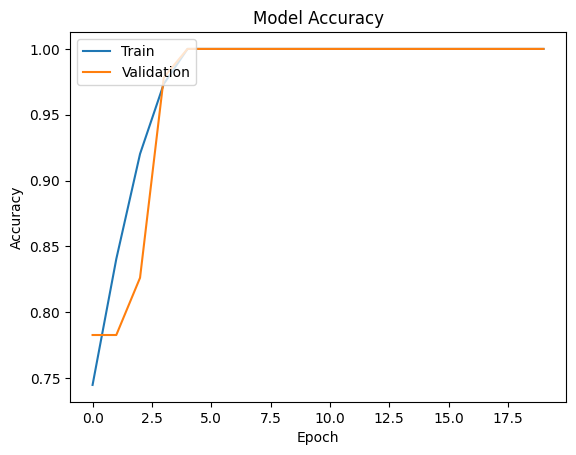

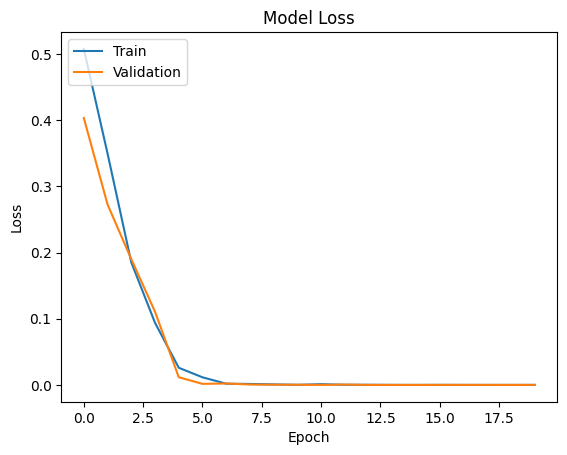

In [1]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras import optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# -------------------------------
# Image Data Preprocessing
# -------------------------------
train_datagen = ImageDataGenerator(
        rescale=1./255,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        validation_split=0.2)  # Use 20% of data for validation

# Train data
training_set = train_datagen.flow_from_directory(
        "/content/drive/MyDrive/Fetal kidney classification",
        target_size=(64, 64),
        batch_size=32,
        class_mode='binary',
        subset='training')

# Validation data
validation_set = train_datagen.flow_from_directory(
        "/content/drive/MyDrive/Fetal kidney classification",
        target_size=(64, 64),
        batch_size=32,
        class_mode='binary',
        subset='validation')

# -------------------------------
# Building the CNN
# -------------------------------
classifier = Sequential()

# 1st Convolution + Pooling
classifier.add(Conv2D(32, (3,3), input_shape=(64, 64, 3), activation='relu'))
classifier.add(MaxPooling2D(pool_size=(2,2)))

# 2nd Convolution + Pooling
classifier.add(Conv2D(64, (3,3), activation='relu'))
classifier.add(MaxPooling2D(pool_size=(2,2)))

# 3rd Convolution + Pooling
classifier.add(Conv2D(128, (3,3), activation='relu'))
classifier.add(MaxPooling2D(pool_size=(2,2)))

# Flattening
classifier.add(Flatten())

# Fully Connected Layers
classifier.add(Dense(256, activation='relu'))
classifier.add(Dropout(0.5))
classifier.add(Dense(1, activation='sigmoid'))  # Binary classification output

# -------------------------------
# Compiling the CNN
# -------------------------------
classifier.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# -------------------------------
# Training the model
# -------------------------------
history = classifier.fit(
    training_set,
    epochs=20,
    validation_data=validation_set
)

# -------------------------------
# Plot accuracy and loss
# -------------------------------
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


In [2]:
# -------------------------------
# Save the trained model
# -------------------------------
classifier.save("kidney_model.h5")

print("✅ Model saved successfully as 'fetal_kidney_classification_model.h5'")

✅ Model saved successfully as 'fetal_kidney_classification_model.h5'


In [9]:
# Install gradio
import gradio as gr
from PIL import Image
import numpy as np
from keras.models import load_model

# Load the saved model
model = load_model("/content/kidney_model.h5")

# Define the prediction function
def predict_kidney(image):
    """Predict the class of the input image"""
    if image is None:
        return "Please upload an image."

    # Preprocess image
    img = image.resize((64, 64))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array)
    # Adjusting the prediction logic based on class indices: {'Abnormal kidney': 0, 'Normal kidney': 1}
    if prediction[0][0] > 0.5:
        result = "Normal Fetal Kidney"
    else:
        result = "Abnormal Fetal Kidney"

    return f"Prediction: {result}"

# Create the Gradio interface
interface = gr.Interface(
    fn=predict_kidney,
    inputs=gr.Image(type="pil", label="Upload Fetal Kidney Image"),
    outputs="text",
    title="Fetal Kidney Classification",
    description="Upload an image of a fetal kidney to get a classification (Normal or Abnormal)."
)

# Launch the interface
interface.launch(inline=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ad54a9e5f06b022b7c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [7]:
print("Class Indices:", training_set.class_indices)

Class Indices: {'Abnormal kidney': 0, 'Normal kidney': 1}
